# ETAP 2: SZKOLENIE I OPTYMALIZACJA MODELI (8 pkt)

Na podstawie wyników z poprzedniego etapu, w którym Las Losowy (Random Forest) osiągnął znacznie lepsze wyniki niż nienadzorowany algorytm K-Means, proces strojenia hiperparametrów zostanie przeprowadzony wyłącznie dla modelu wiodącego (Lasu Losowego). 

W tym kroku:
1. Wczytujemy lokalny zestaw danych z pliku `.csv`.
2. Budujemy potok przetwarzania danych (Pipeline).
3. Wykorzystujemy `GridSearchCV` (przeszukiwanie siatki z 5-krotną walidacją krzyżową), aby przetestować różne kombinacje budowy lasu i znaleźć optymalne parametry chroniące przed przeuczeniem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

sns.set_theme(style="whitegrid")

# ==========================================
# 1. WCZYTANIE LOKALNEGO ZBIORU DANYCH
# ==========================================
print("Wczytywanie lokalnego pliku CSV...")
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print(f"Sukces! Liczba załadowanych rekordów: {len(df)}")

# Ujednolicenie nazw kolumn (małe litery, brak spacji), żeby uniknąć głupich błędów
df.columns = df.columns.str.strip().str.lower()

# Odszukanie zmiennej docelowej (depression_label)
target_col = 'depression_label' if 'depression_label' in df.columns else df.columns[-1]

# ==========================================
# 2. PODZIAŁ I PREPROCESSING
# ==========================================
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print("Zbiór danych został pomyślnie przetworzony i podzielony na zbiór treningowy i testowy.")

Wczytywanie lokalnego pliku CSV...
Sukces! Liczba załadowanych rekordów: 1200
Zbiór danych został pomyślnie przetworzony i podzielony na zbiór treningowy i testowy.


C:\Users\Kacper\AppData\Local\Temp\ipykernel_26848\2673635056.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


### Strojenie Hiperparametrów (GridSearchCV)
Zamiast używać domyślnych ustawień, przetestujemy różne kombinacje budowy Lasu Losowego.

In [2]:
# ==========================================
# 3. STROJENIE HIPERPARAMETRÓW (GridSearchCV)
# ==========================================

# Tworzymy bazowy rurociąg dla Lasu Losowego
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Definiujemy siatkę parametrów do przetestowania
param_grid = {
    'classifier__n_estimators': [50, 100, 200],         # Liczba drzew w lesie
    'classifier__max_depth': [None, 5, 10, 15],         # Maksymalna głębokość pojedynczego drzewa
    'classifier__min_samples_split': [2, 5, 10]         # Minimalna liczba próbek do podziału węzła
}

print("Rozpoczynam strojenie parametrów (GridSearchCV) z 5-krotną walidacją krzyżową...")
print("To może zająć kilkanaście sekund...\n")

grid_search = GridSearchCV(
    rf_pipeline, 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,  # -1 oznacza użycie wszystkich dostępnych rdzeni procesora
    verbose=1
)

# Trenowanie z optymalizacją
grid_search.fit(X_train, y_train)

print("\n--- ZAKOŃCZONO OPTYMALIZACJĘ ---")
print("Najlepsze znalezione hiperparametry:")
for param, value in grid_search.best_params_.items():
    print(f" -> {param.replace('classifier__', '')}: {value}")

print(f"\nNajwyższa skuteczność (Accuracy) podczas walidacji treningowej: {grid_search.best_score_:.4f}")

Rozpoczynam strojenie parametrów (GridSearchCV) z 5-krotną walidacją krzyżową...
To może zająć kilkanaście sekund...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

--- ZAKOŃCZONO OPTYMALIZACJĘ ---
Najlepsze znalezione hiperparametry:
 -> max_depth: None
 -> min_samples_split: 2
 -> n_estimators: 50

Najwyższa skuteczność (Accuracy) podczas walidacji treningowej: 0.9771


### Ewaluacja Zoptymalizowanego Modelu
Sprawdzamy, jak wyłoniony najlepszy model radzi sobie na danych testowych (których nigdy wcześniej nie widział) i porównujemy go z modelem domyślnym.

RAPORT ZOPTYMALIZOWANEGO MODELU (Zbiór Testowy)
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       234
           1       0.00      0.00      0.00         6

    accuracy                           0.97       240
   macro avg       0.49      0.50      0.49       240
weighted avg       0.95      0.97      0.96       240



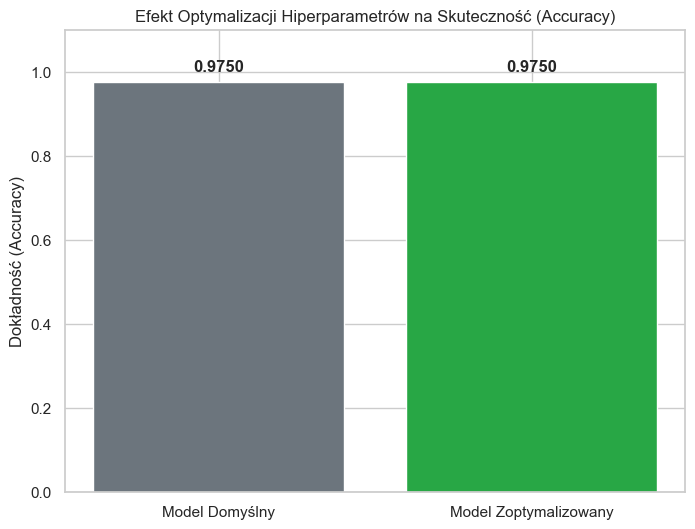

In [3]:
# ==========================================
# 4. EWALUACJA ZOPTYMALIZOWANEGO MODELU NA ZBIORZE TESTOWYM
# ==========================================

# Pobieramy najlepszy model wybrany przez GridSearchCV
best_rf_model = grid_search.best_estimator_

# Generujemy predykcje dla zbioru testowego
y_pred_best = best_rf_model.predict(X_test)

print("=========================================")
print("RAPORT ZOPTYMALIZOWANEGO MODELU (Zbiór Testowy)")
print("=========================================")
print(classification_report(y_test, y_pred_best, zero_division=0))

# Porównanie z modelem domyślnym (bez strojenia) dla wizualizacji
rf_baseline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))])
rf_baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, rf_baseline.predict(X_test))
optimized_acc = accuracy_score(y_test, y_pred_best)

# Wykres efektów optymalizacji
plt.figure(figsize=(8, 6))
bars = plt.bar(['Model Domyślny', 'Model Zoptymalizowany'], [baseline_acc, optimized_acc], color=['#6c757d', '#28a745'])
plt.title('Efekt Optymalizacji Hiperparametrów na Skuteczność (Accuracy)')
plt.ylim(0, 1.1)
plt.ylabel('Dokładność (Accuracy)')

# Dodanie wartości procentowych nad słupkami
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.show()